# PQL Docs — Chunking Strategy Analysis

Goal: understand the corpus well enough to decide on a chunking strategy.

Sections:
1. Setup
2. What are these documents? (types, structure, content)
3. Length distribution
4. Structural elements deep-dive

## 1. Setup

In [1]:
!pip install tiktoken seaborn --quiet

In [7]:
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/scrape/pql_docs.jsonl'

records = []
with open(DATA_PATH) as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)

enc = tiktoken.get_encoding('cl100k_base')
df['token_count'] = df['full_content'].apply(lambda t: len(enc.encode(t)) if isinstance(t, str) else 0)

print(f'Loaded {len(df)} documents')

Loaded 291 documents


## 2. What are these documents?

Before looking at numbers, let's understand what we're actually dealing with — content type, structure, and patterns.

In [8]:
# --- Structural flags per document ---
def analyze_doc(text):
    if not isinstance(text, str):
        return {}
    lines = text.split('\n')
    return {
        'has_table':    any('|' in l for l in lines),
        'has_example':  bool(re.search(r'(?i)\bexample\b', text)),
        'has_note':     bool(re.search(r'(?i)^note\b', text, re.MULTILINE)),
        'has_code_block': bool(re.search(r'```', text)),
        'has_inline_code': bool(re.search(r'`[^`\n]+`', text)),
        'has_list':     any(re.match(r'^\s*[-*+]\s|^\s*\d+\.\s', l) for l in lines),
        'h1_count':     sum(1 for l in lines if re.match(r'^# [^#]', l)),
        'h2_count':     sum(1 for l in lines if re.match(r'^## [^#]', l)),
        'h3_count':     sum(1 for l in lines if re.match(r'^### ', l)),
    }

flags = df['full_content'].apply(analyze_doc).apply(pd.Series)
df = pd.concat([df, flags], axis=1)

n = len(df)
print('=== Document structure overview ===')
for col in ['has_table', 'has_example', 'has_note', 'has_code_block', 'has_inline_code', 'has_list']:
    count = df[col].sum()
    print(f'  {col:<22} {count:>3} / {n}  ({count/n*100:.0f}%)')

=== Document structure overview ===
  has_table               29 / 291  (10%)
  has_example            202 / 291  (69%)
  has_note                 0 / 291  (0%)
  has_code_block           0 / 291  (0%)
  has_inline_code          0 / 291  (0%)
  has_list                 0 / 291  (0%)


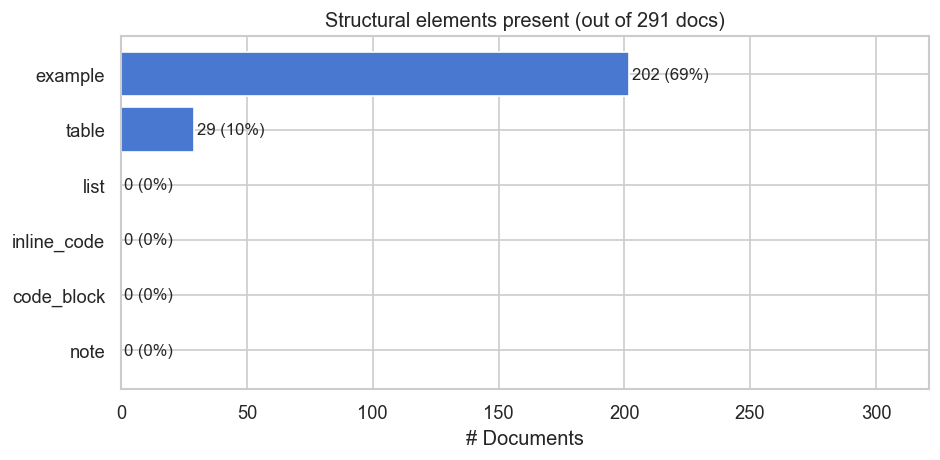

In [9]:
# Visual: which features co-occur?
feature_cols = ['has_table', 'has_example', 'has_note', 'has_code_block', 'has_inline_code', 'has_list']
counts = df[feature_cols].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(counts.index.str.replace('has_', ''), counts.values)
for bar, v in zip(bars, counts.values):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v} ({v/n*100:.0f}%)',
            va='center', fontsize=10)
ax.set_xlabel('# Documents')
ax.set_title(f'Structural elements present (out of {n} docs)')
ax.set_xlim(0, n + 30)
plt.tight_layout()
plt.show()

In [10]:
# Show a sample doc with a table to understand the format
sample = df[df['has_table']].iloc[0]
print(f'Sample doc with table: "{sample["title"]}"')
print('---')
# Find and print the table section
lines = sample['full_content'].split('\n')
for i, line in enumerate(lines):
    if '|' in line:
        start = max(0, i-3)
        end = min(len(lines), i+10)
        print('\n'.join(lines[start:end]))
        break

Sample doc with table: "PQL Function Library"
---
PQL Function Library Description PQL provides a wide variety of functions and operators that can be used within a query. This sections contains all available functions and operators. In contrast to operators, functions obey a strict syntax of listing function parameters - especially the more complex ones like CASE WHEN . Deprecated Operators You might find that some of your favorite operators have an annotation that marks them as being deprecated. This means there is a new operator that can be used for solving the same problem. The new operator probably supports more functionality, can be more performant or easier to use. If an operator is marked as deprecated, we recommend to use the new operator, which should be linked in the documentation. There will be no new features added to the deprecated operator, only to the replacement. As long as it is not marked with a removal date, we do not plan to remove the operator any time soon, so you

In [11]:
# Show a sample doc with an example section
sample = df[df['has_example']].iloc[2]
print(f'Sample doc with example: "{sample["title"]}"')
print('---')
text = sample['full_content']
# Find the example region
m = re.search(r'(?i)example', text)
if m:
    print(text[max(0, m.start()-100):m.start()+500])

Sample doc with example: "Automerge"
---
 content of the default columns from the activity tables and replace the original column names. For example, if there is the activity table "O2C_ACTIVITIES" with the activity column "ACTIVITY_EN" , the merged result would be in "_CEL_MERGED_ACTIVITIES"."ACTIVITY" . All other columns of the data model activity tables are also merged and added to the result table under their original name. If activity tables have the same column name but different types, separate columns are added to the table _CEL_MERGED_ACTIVITIES. We assign them a name that is the concatenation of the column name and the colu


In [12]:
# Header depth: how are docs organized?
print('Header depth across corpus:')
print(f"  Docs with H1: {df['h1_count'].gt(0).sum()} ({df['h1_count'].gt(0).mean()*100:.0f}%)")
print(f"  Docs with H2: {df['h2_count'].gt(0).sum()} ({df['h2_count'].gt(0).mean()*100:.0f}%)")
print(f"  Docs with H3: {df['h3_count'].gt(0).sum()} ({df['h3_count'].gt(0).mean()*100:.0f}%)")
print()
print('Avg headers per doc:')
print(f"  H1: {df['h1_count'].mean():.1f}")
print(f"  H2: {df['h2_count'].mean():.1f}")
print(f"  H3: {df['h3_count'].mean():.1f}")
print()
# Common document skeleton
print('Most common H1 headers (document title pattern):')
h1_samples = []
for text in df['full_content']:
    if not isinstance(text, str): continue
    for line in text.split('\n'):
        if re.match(r'^# [^#]', line):
            h1_samples.append(line.strip())
            break
print(pd.Series(h1_samples).value_counts().head(10).to_string())

Header depth across corpus:
  Docs with H1: 0 (0%)
  Docs with H2: 0 (0%)
  Docs with H3: 0 (0%)

Avg headers per doc:
  H1: 0.0
  H2: 0.0
  H3: 0.0

Most common H1 headers (document title pattern):
Series([], )


In [13]:
# Print a full short doc to see the typical skeleton
short_docs = df[(df['token_count'] > 100) & (df['token_count'] < 300)].sort_values('token_count')
sample = short_docs.iloc[2]
print(f'Sample short doc: "{sample["title"]}" ({sample["token_count"]} tokens)')
print('===')
print(sample['full_content'])

Sample short doc: "SQUARE" (118 tokens)
===
SQUARE Description The SQUARE function calculates the square for each input value. Can be applied to INT or FLOAT columns. The resulting column is of type FLOAT . Syntax SQUARE ( table.column ) NULL handling If one of the input values is NULL, the result is NULL as well. Example [1] Calculate the square of three Integers Query Column1 SQUARE ( "Table1"."Column1" ) Input Output Table1 Column1 : int 1 2 3 null Result Column1 : float 1.0 4.0 9.0 null See also: SQRT POWER


## 3. Length Distribution

In [14]:
print('=== Token count stats ===')
print(df['token_count'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).round(0).to_string())

=== Token count stats ===
count      291.0
mean      1283.0
std       2114.0
min         11.0
10%        135.0
25%        299.0
50%        624.0
75%       1496.0
90%       2737.0
95%       4634.0
99%       8833.0
max      25146.0


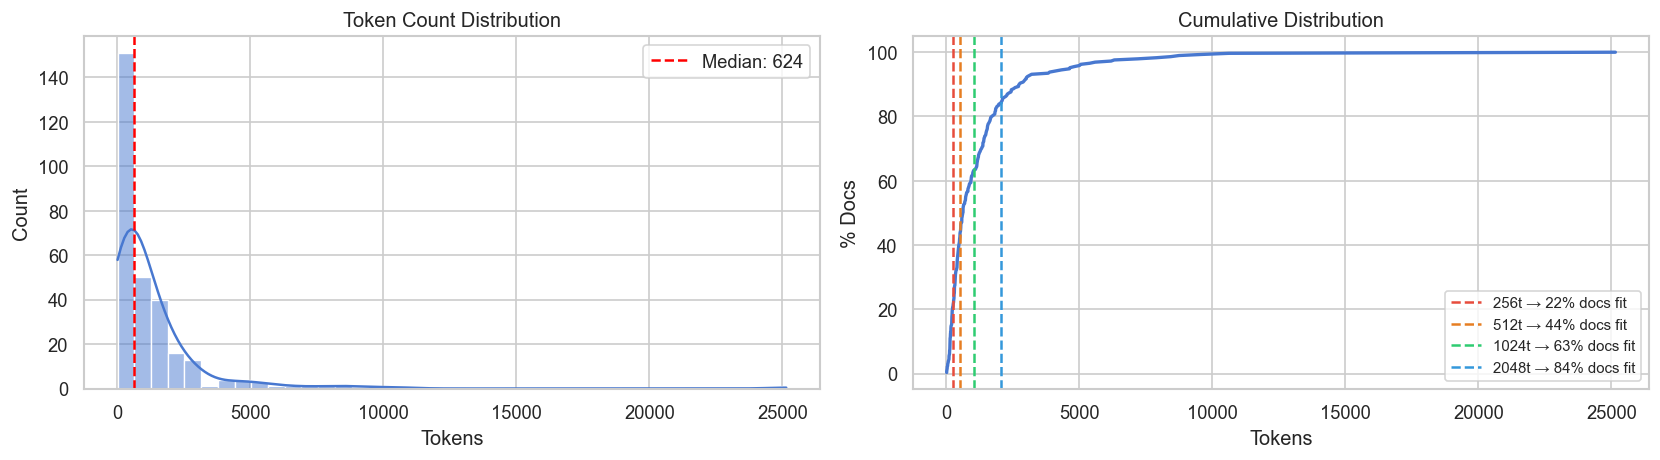

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
sns.histplot(df['token_count'], bins=40, ax=axes[0], kde=True)
axes[0].axvline(df['token_count'].median(), color='red', linestyle='--',
                label=f'Median: {df["token_count"].median():.0f}')
axes[0].set_title('Token Count Distribution')
axes[0].set_xlabel('Tokens')
axes[0].legend()

# CDF with common chunk size markers
sorted_t = np.sort(df['token_count'])
cdf = np.arange(1, len(sorted_t)+1) / len(sorted_t) * 100
axes[1].plot(sorted_t, cdf, linewidth=2)
for size, color in zip([256, 512, 1024, 2048], ['#e74c3c','#e67e22','#2ecc71','#3498db']):
    pct = (df['token_count'] <= size).mean() * 100
    axes[1].axvline(size, color=color, linestyle='--',
                    label=f'{size}t → {pct:.0f}% docs fit')
axes[1].set_title('Cumulative Distribution')
axes[1].set_xlabel('Tokens')
axes[1].set_ylabel('% Docs')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
# Tiny and giant docs
tiny  = df[df['token_count'] < 50][['title','token_count']].sort_values('token_count')
giant = df[df['token_count'] > 2000][['title','token_count']].sort_values('token_count', ascending=False)
print(f'Tiny docs (< 50 tokens): {len(tiny)}')
print(tiny.to_string(index=False))
print()
print(f'Giant docs (> 2000 tokens): {len(giant)}')
print(giant.to_string(index=False))

Tiny docs (< 50 tokens): 8
                     title  token_count
                  Currency           11
                    Custom           11
             Miscellaneous           17
              Cheat Sheets           22
               Aggregation           30
Machine Learning Functions           30
                      Math           45
             Set Operators           48

Giant docs (> 2000 tokens): 47
                                      title  token_count
                           WORKDAY_CALENDAR        25146
                            CREATE_EVENTLOG        10617
                        MATCH_PROCESS_REGEX         9622
   MERGE_EVENTLOG - MERGE_EVENTLOG_DISTINCT         8745
                                  LINK_PATH         8436
                             TRANSIT_COLUMN         7885
                                LINK_FILTER         7191
                      Catalog Tables - OCPM         6311
                              BPMN_CONFORMS         6192
           

## 4. Structural Elements Deep-Dive

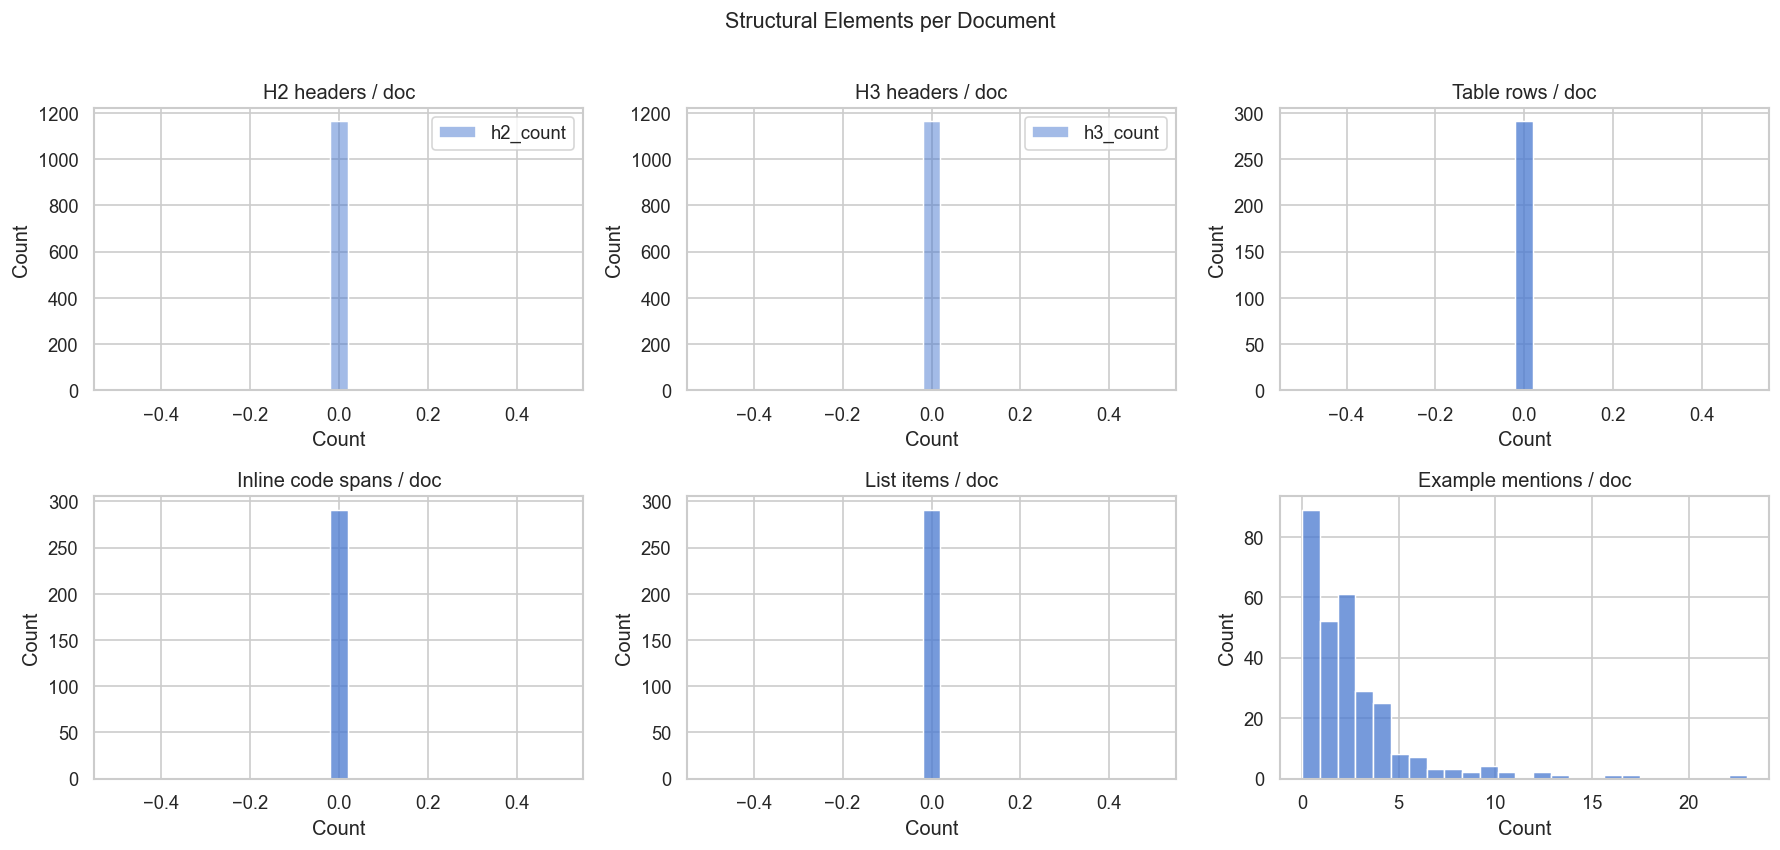

In [17]:
# Count granular structural elements
def count_structure(text):
    if not isinstance(text, str):
        return {}
    lines = text.split('\n')
    return {
        'h2_count':          sum(1 for l in lines if re.match(r'^## [^#]', l)),
        'h3_count':          sum(1 for l in lines if re.match(r'^### ', l)),
        'table_rows':        sum(1 for l in lines if l.strip().startswith('|') and '|' in l[1:]),
        'inline_code_count': len(re.findall(r'`[^`\n]+`', text)),
        'list_items':        sum(1 for l in lines if re.match(r'^\s*[-*+]\s|^\s*\d+\.\s', l)),
        'example_mentions':  len(re.findall(r'(?i)\bexample\b', text)),
    }

counts = df['full_content'].apply(count_structure).apply(pd.Series)
df = pd.concat([df, counts], axis=1)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
cols = ['h2_count', 'h3_count', 'table_rows', 'inline_code_count', 'list_items', 'example_mentions']
labels = ['H2 headers / doc', 'H3 headers / doc', 'Table rows / doc',
          'Inline code spans / doc', 'List items / doc', 'Example mentions / doc']

for ax, col, label in zip(axes, cols, labels):
    sns.histplot(df[col], bins=25, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('Count')

plt.suptitle('Structural Elements per Document', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

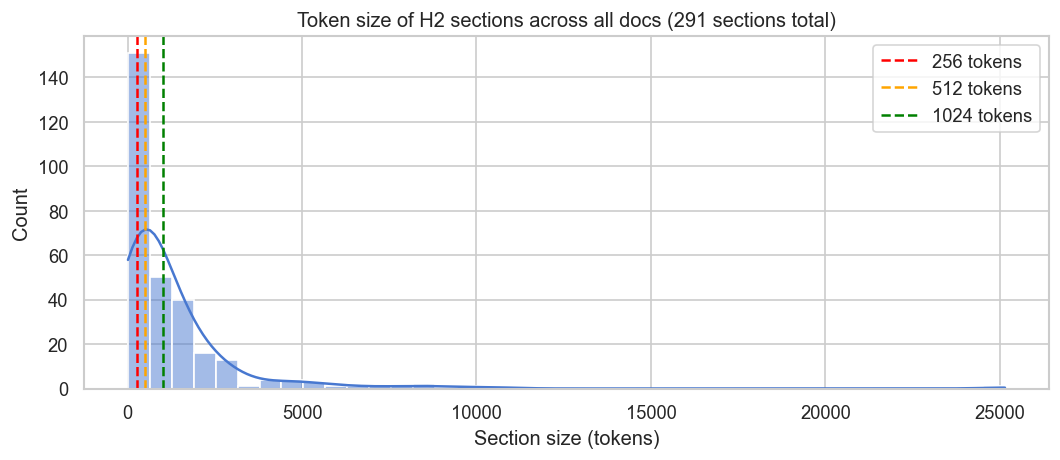

Mean section: 1283 tokens | Median: 624 | Max: 25146


In [18]:
# H2 section length — key for header-based chunking viability
def h2_section_tokens(text):
    if not isinstance(text, str): return []
    sections = re.split(r'(?m)^(?=## )', text)
    return [len(enc.encode(s)) for s in sections if s.strip()]

section_sizes = [s for text in df['full_content'] for s in h2_section_tokens(text)]

if section_sizes:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(section_sizes, bins=40, ax=ax, kde=True)
    for size, color in zip([256, 512, 1024], ['red','orange','green']):
        ax.axvline(size, color=color, linestyle='--', label=f'{size} tokens')
    ax.set_xlabel('Section size (tokens)')
    ax.set_title(f'Token size of H2 sections across all docs ({len(section_sizes)} sections total)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'Mean section: {np.mean(section_sizes):.0f} tokens | Median: {np.median(section_sizes):.0f} | Max: {max(section_sizes)}')

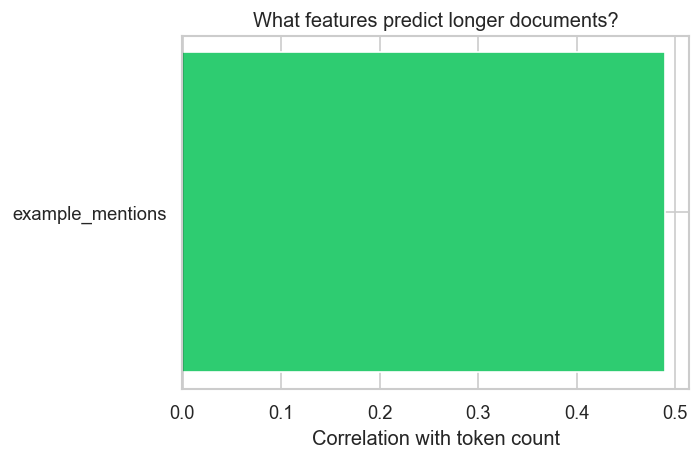

In [19]:
# Correlation: which features correlate with longer docs?
corr_cols = ['h2_count', 'h3_count', 'table_rows', 'inline_code_count', 'list_items', 'example_mentions', 'token_count']
corr = df[corr_cols].corr()[['token_count']].drop('token_count').sort_values('token_count', ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr['token_count']]
ax.barh(corr.index, corr['token_count'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with token count')
ax.set_title('What features predict longer documents?')
plt.tight_layout()
plt.show()